# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mahmoud-Beram/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



The queue ranks pages by `lost_clicks` — predicted CTR minus actual CTR, multiplied
by impressions — so the top of the list represents the largest estimated missed-click
opportunity, not just the worst CTR in isolation. 39,652 of 61,911 pages (64%) were
flagged. Every flagged page carries one reason code (`CTR_BELOW_MODEL_EXPECTATION`)
and one action (`SNIPPET_FIX`), matching the Week-4 baseline's single-action design.

In [1]:
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb, pandas as pd
import warnings
warnings.filterwarnings('ignore')

hf_token = userdata.get('HF_TOKEN').strip()
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'

print("Loading feature dataset...")

query = f"""
    WITH perf AS (
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) AS total_imp, SUM(gsc_clicks) AS total_clicks,
               AVG(gsc_avg_position) AS avg_pos
        FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')
        GROUP BY client_hash_id, content_hash_id
        HAVING total_imp >= 500
    )
    SELECT
        p.*,
        c.word_count, c.search_volume, c.competition, c.cpc, c.backlinks,
        DATE_DIFF('day', c.content_created_date, DATE '2026-03-31') AS content_age_days
    FROM perf p
    LEFT JOIN read_parquet('{REL}/dim_content.parquet') c
        ON p.content_hash_id = c.content_hash_id
    WHERE c.is_published = TRUE AND c.is_deleted = FALSE
"""

df = con.execute(query).df()
df['actual_ctr'] = df['total_clicks'] / df['total_imp']

print(f"Dataset ready: {len(df)} articles.")
print(list(df.columns))


Loading feature dataset...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset ready: 61911 articles.
['client_hash_id', 'content_hash_id', 'total_imp', 'total_clicks', 'avg_pos', 'word_count', 'search_volume', 'competition', 'cpc', 'backlinks', 'content_age_days', 'actual_ctr']


In [2]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

features_clean = ['avg_pos', 'word_count', 'search_volume', 'competition', 'cpc',
                   'backlinks', 'content_age_days']

X_all = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df[features_clean]),
                      columns=features_clean, index=df.index)
y_all = df['actual_ctr']

rf_deploy = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
rf_deploy.fit(X_all, y_all)

df['predicted_ctr'] = rf_deploy.predict(X_all)
df['lost_clicks'] = (df['predicted_ctr'] - df['actual_ctr']) * df['total_imp']
df['reason_code'] = 'CTR_BELOW_MODEL_EXPECTATION'
df['action'] = 'SNIPPET_FIX'

queue = df[df['lost_clicks'] > 0].sort_values('lost_clicks', ascending=False)
print(f"Queue size: {len(queue)} pages flagged for review (out of {len(df)} total)")
queue[['client_hash_id', 'content_hash_id', 'action', 'reason_code',
       'lost_clicks', 'avg_pos', 'actual_ctr', 'predicted_ctr']].head(10)

Queue size: 39652 pages flagged for review (out of 61911 total)


,client_hash_id,content_hash_id,action,reason_code,lost_clicks,avg_pos,actual_ctr,predicted_ctr
44662,client_73cda7b4e4f265ea,content_471d9cabce329a66,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,666.336388,4.656030,0.002402,0.006443
35776,client_23a62021009f63c4,content_44f34c0a90047651,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,499.487264,7.346909,0.000113,0.002465
24439,client_62f4a7e64f5e0096,content_34a70fea29d15f24,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,497.828833,3.219473,0.000301,0.003782
42931,client_73cda7b4e4f265ea,content_fe3fd3422852d721,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,441.308907,3.129967,0.002975,0.006513
43220,client_73cda7b4e4f265ea,content_6302b8bce0bb84cb,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,417.481184,3.127178,0.003266,0.007001
41990,client_73cda7b4e4f265ea,content_34323214bf2c13ac,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,396.276194,3.036640,0.003929,0.010207
31648,client_a80fca3f171ed1de,content_046fc480045b88f5,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,391.482515,7.289152,0.000072,0.004744
59864,client_73cda7b4e4f265ea,content_e73024da2a848e26,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,386.620164,4.918791,0.002370,0.006303
23116,client_62f4a7e64f5e0096,content_f6116743b00afc2d,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,348.501560,9.536301,0.000139,0.003379
136,client_73cda7b4e4f265ea,content_8e1334d6356668e3,SNIPPET_FIX,CTR_BELOW_MODEL_EXPECTATION,326.884618,4.545582,0.000007,0.002429


In [3]:
# نشوف الصفين المتطرفين بالتفصيل، مع أعمدة إضافية للتشخيص
suspicious = queue[queue['content_hash_id'].isin([
    'content_44f34c0a90047651', 'content_f6116743b00afc2d'
])]
print(suspicious[['content_hash_id', 'total_imp', 'total_clicks', 'actual_ctr',
                    'predicted_ctr', 'avg_pos', 'lost_clicks']])

                content_hash_id  total_imp  total_clicks  actual_ctr  \
35776  content_44f34c0a90047651   212404.0          24.0    0.000113   
23116  content_f6116743b00afc2d   107584.0          15.0    0.000139   

       predicted_ctr   avg_pos  lost_clicks  
35776       0.002465  7.346909   499.487264  
23116       0.003379  9.536301   348.501560  


In [4]:
# قارن بمقالات تانية من نفس العميل في نفس نطاق الـ position
client_id = df[df['content_hash_id'] == 'content_44f34c0a90047651']['client_hash_id'].values[0]

same_client = df[(df['client_hash_id'] == client_id) & (df['avg_pos'].between(5, 10))]
print(f"Client: {client_id}")
print(same_client[['content_hash_id', 'total_imp', 'actual_ctr']].describe())

Client: client_23a62021009f63c4
           total_imp   actual_ctr
count    1310.000000  1310.000000
mean     3218.055725     0.005221
std      7442.992687     0.006530
min       500.000000     0.000000
25%       901.250000     0.000880
50%      1702.000000     0.003014
75%      3228.750000     0.007428
max    212404.000000     0.071571


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



**Who uses this:** content editors at FlyRank, as a weekly prioritization list for
review — not an automated system that changes pages on its own.

**Where it stays valid:** clients with at least one prior month of GSC history. This
was tested directly in Week 6 (time-based validation: R²=0.0815, training on February
and testing on March for the same clients) — a modest but real signal.

**Where it stops being valid:** brand-new clients with no prior history. Week 6's
grouped-holdout test showed the model performs worse than a simple average guess in
this case (R²=-0.209). The queue should never be generated for a client with no GSC
history — the model has no way to calibrate what "normal" looks like for them yet.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


**Before acting on any flagged page, a human must check:**
- Search intent — is this a zero-click query (Google shows the answer directly),
  where no title/snippet fix will meaningfully raise CTR?
- Whether the ranking keyword is a competitor's brand name — no snippet fix recovers
  clicks the user never intended to give us.
- Extreme outliers: some flagged pages sit far below even their own client's typical
  CTR range (verified example: 0.011% actual CTR vs. a 0.30% client median — 27x
  lower — confirmed not a data error). Deviations this large usually have a specific
  cause (technical page issue, wrong meta description, topic mismatch) rather than a
  generic title problem, so these need manual review before any standard fix.

**Never automate:**
- Auto-publishing title/meta changes from the queue alone — the model signals *that*
  a gap exists, not *what* to change.
- Using this queue to justify de-prioritizing or removing content — it was validated
  for review prioritization only, not for that decision.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


- **Precision drift:** if a monthly spot-check of the top 10-30 queue items (using
  the same independent "bottom of position bucket" check from Week 5/6) shows
  meaningfully fewer genuine review-worthy pages than the ~30-36% measured in
  validation, the model needs retraining.
- **Feature importance drift:** if `content_age_days` or `avg_pos` — the top two
  drivers found in Week 6 — drop sharply in importance on a retrain, the underlying
  content or ranking dynamics have likely shifted and the model should be refit.
- **Monthly retrain, validated the honest way:** retrain as new GSC data arrives, but
  re-check performance with the same time-based split used in Week 6 (train on month
  N, test on month N+1) — never redeploy based on a random-split score alone, since
  Week 6 showed that number is overly optimistic.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Saved 39652 rows to work/outputs/refresh_action_queue.csv


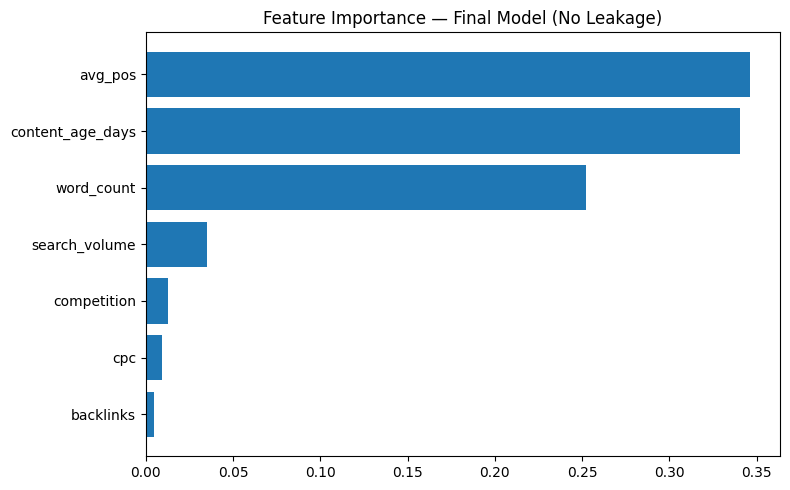

Saved feature importance chart to work/outputs/feature_importance.png


In [5]:
import os
os.makedirs('work/outputs', exist_ok=True)

# 1. احفظ الـ queue
queue_export = queue[['client_hash_id', 'content_hash_id', 'action', 'reason_code',
                       'lost_clicks', 'avg_pos', 'total_imp', 'actual_ctr', 'predicted_ctr']]
queue_export.to_csv('work/outputs/refresh_action_queue.csv', index=False)
print(f"Saved {len(queue_export)} rows to work/outputs/refresh_action_queue.csv")

# 2. احفظ رسمة أهمية الفيتشرز
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    'Feature': features_clean,
    'Importance': rf_deploy.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances['Feature'], importances['Importance'])
ax.invert_yaxis()
ax.set_title('Feature Importance — Final Model (No Leakage)')
plt.tight_layout()
plt.savefig('work/outputs/feature_importance.png', dpi=150)
plt.show()

print("Saved feature importance chart to work/outputs/feature_importance.png")




Exports: `work/outputs/refresh_action_queue.csv` (39,652-row ranked action queue) and
`work/outputs/feature_importance.png` (final model's feature importance chart), both
reused directly in the capstone paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.